# Problem Set 2 — Solutions

**OE 754/854 — Ocean Waves & Tides**

Topics: boundary conditions, BVP formulation, linearization, numerical dispersion.

Released after the PS2 submission deadline. Homework is graded for submission only, so nothing here is a rubric. Compare it with what you wrote. Whatever differs is what to review before the exams. Each derivation below is followed by a short numerical check. Run the notebook top to bottom (keep `solutions/` and `notebooks/` as sibling directories so the shared figure style imports).

Companion notebooks:

- `week04_bvp.ipynb`: the boundary-value-problem setup, the numerical Laplacian check, and the free-surface conditions at three levels of approximation.
- `week05_airy_dispersion.ipynb`: the three dispersion solvers of Problem 7, and the relation $\omega^2 = gk\tanh kh$ that closes the BVP.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import figure_style as fs

g = 9.81
rho = 1000.0

## Problem 1. KFSBC from the material derivative.

The free surface is $z = \eta(x, y, t)$. A parcel on the surface stays on the surface, so $F(\vec{x}, t) = z - \eta(x, y, t)$ satisfies $\dfrac{DF}{Dt} = 0$ there.

**(a) Derivation.** Expand the material derivative of $F$ term by term:

$$
\frac{DF}{Dt}
= \frac{\partial F}{\partial t}
+ u\frac{\partial F}{\partial x}
+ v\frac{\partial F}{\partial y}
+ w\frac{\partial F}{\partial z}.
$$

Each partial derivative of $F = z - \eta(x, y, t)$ is explicit:

$$
\frac{\partial F}{\partial t} = -\frac{\partial\eta}{\partial t},
\qquad
\frac{\partial F}{\partial x} = -\frac{\partial\eta}{\partial x},
\qquad
\frac{\partial F}{\partial y} = -\frac{\partial\eta}{\partial y},
\qquad
\frac{\partial F}{\partial z} = 1,
$$

since $\eta$ does not depend on $z$, and $z$ does not depend on $(x, y, t)$. Substituting,

$$
\frac{DF}{Dt}
= -\frac{\partial\eta}{\partial t}
- u\frac{\partial\eta}{\partial x}
- v\frac{\partial\eta}{\partial y}
+ w = 0
\qquad\text{at } z = \eta,
$$

and rearranging gives the kinematic free-surface boundary condition:

$$
\frac{\partial\eta}{\partial t}
+ u\frac{\partial\eta}{\partial x}
+ v\frac{\partial\eta}{\partial y}
= w,
\qquad\text{at } z = \eta(x, y, t). \qquad\blacksquare
$$

Physically: the surface rises ($\partial\eta/\partial t$) for one of two reasons. Either fluid moves up through it ($w$), or the sloping surface is swept past a fixed observer ($u\,\partial\eta/\partial x + v\,\partial\eta/\partial y$).

**(b) 2D form and linearization.** With $v = 0$ and $\partial\eta/\partial y = 0$,

$$
\frac{\partial\eta}{\partial t} + u\frac{\partial\eta}{\partial x} = w,
\qquad\text{at } z = \eta(x, t).
$$

Linearization drops the advective term $u\,\partial\eta/\partial x$ (and evaluates the rest at $z = 0$ instead of $z = \eta$). For the scaling argument, take $\eta = a\cos(kx - \omega t)$. Each linear field scales as

$$
\frac{\partial\eta}{\partial t} \sim \omega a,
\qquad
u \sim \omega a,
\qquad
\frac{\partial\eta}{\partial x} \sim ka,
\qquad
w \sim \omega a,
$$

so the retained terms are $\mathcal{O}(a)$ while the dropped term is a *product of two first-order quantities*:

$$
u\frac{\partial\eta}{\partial x} \sim (\omega a)(ka) = \mathcal{O}(a^2),
\qquad
\frac{u\,\partial\eta/\partial x}{\partial\eta/\partial t}
\sim \frac{(\omega a)(ka)}{\omega a} = ka = \varepsilon.
$$

For small steepness $\varepsilon = ka \ll 1$ the advective term is smaller than the retained terms by a factor $\varepsilon$. Moving the evaluation point from $z = \eta$ to $z = 0$ is consistent at the same order. Taylor expansion of any field $f(z)$ gives $f(\eta) = f(0) + \eta\,f'(0) + \cdots$. The correction $\eta\,f'(0) \sim a \cdot k \cdot f$ is again $\mathcal{O}(\varepsilon)$ relative to $f(0)$.

In [2]:
# KFSBC residual of the linear Airy fields, evaluated at the exact surface z = eta.
# Residual normalized by (a*omega) should scale like ka (i.e., quadratic in a).
h_dep = 10.0
k = 2 * np.pi / 40.0
om = np.sqrt(g * k * np.tanh(k * h_dep))
theta = np.linspace(0, 2 * np.pi, 400)

print(f"{'ka':>6}  {'max|u eta_x| / max|eta_t|':>27}  {'max|KFSBC resid|/(a om)':>24}")
for ka in [0.01, 0.05, 0.1, 0.2]:
    a = ka / k
    eta = a * np.cos(theta)
    eta_t = a * om * np.sin(theta)
    eta_x = -a * k * np.sin(theta)
    u_s = a * om * np.cosh(k * (h_dep + eta)) / np.sinh(k * h_dep) * np.cos(theta)
    w_s = a * om * np.sinh(k * (h_dep + eta)) / np.sinh(k * h_dep) * np.sin(theta)
    resid = eta_t + u_s * eta_x - w_s
    ratio = np.abs(u_s * eta_x).max() / np.abs(eta_t).max()
    print(f"{ka:6.2f}  {ratio:27.4f}  {np.abs(resid).max() / (a * om):24.4f}")
print("\nBoth columns track ka: the dropped term and the residual are O(eps) relative to O(a) terms.")

    ka    max|u eta_x| / max|eta_t|   max|KFSBC resid|/(a om)
  0.01                       0.0055                    0.0110
  0.05                       0.0282                    0.0559
  0.10                       0.0582                    0.1146
  0.20                       0.1246                    0.2411

Both columns track ka: the dropped term and the residual are O(eps) relative to O(a) terms.


## Problem 2. Sloping bottom.

The bed is $z = -h(x)$ with $h > 0$ the local depth. It is rigid and impermeable, so $\vec{u}\cdot\hat{n} = 0$ on it.

**(a) The normal.** Describe the bed as the level set

$$
G(x, z) = z + h(x) = 0.
$$

The fluid occupies $G > 0$ (i.e., $z > -h$). The gradient of $G$ points toward increasing $G$, so into the fluid. With $h' = \partial h/\partial x$:

$$
\nabla G = \left(\frac{\partial G}{\partial x},\ \frac{\partial G}{\partial y},\ \frac{\partial G}{\partial z}\right)
= \left(h'(x),\ 0,\ 1\right),
$$

so the unit normal into the fluid is

$$
\hat{n} = \frac{\nabla G}{|\nabla G|}
= \frac{\left(h',\ 0,\ 1\right)}{\sqrt{1 + (h')^2}}.
$$

For a flat bed ($h' = 0$) this reduces to $\hat{n} = \hat{z}$, straight up.

**(b) The boundary condition.** Impose no flux through the bed:

$$
\vec{u}\cdot\hat{n}
= \frac{u\,h' + v\cdot 0 + w\cdot 1}{\sqrt{1 + (h')^2}} = 0
\qquad\text{at } z = -h(x).
$$

The denominator never vanishes, so the numerator must:

$$
w + u\frac{\partial h}{\partial x} = 0
\quad\Longleftrightarrow\quad
w = -u\frac{\partial h}{\partial x},
\qquad\text{at } z = -h(x). \qquad\blacksquare
$$

So fluid at the bed flows *along* the bed. Where the flow runs toward shallower water ($u > 0$, $h' < 0$), the bed forces the near-bed fluid upward ($w > 0$).

**(c) When is $u\,\partial h/\partial x$ negligible?** Scale the two terms at the bed. The bottom slope is $m = |\partial h/\partial x|$. Near-bed velocities scale with the wave orbital velocity there: $u \sim \omega a\,/\sinh kh$ (up to the $\cosh$/$\sinh$ vertical structure). The slope term is then

$$
u\frac{\partial h}{\partial x} \sim m\,u_{\mathrm{bed}},
\qquad\text{versus}\qquad
w_{\mathrm{bed}} \sim u_{\mathrm{bed}} \times \mathcal{O}(m)\ \text{(forced by the slope itself)},
$$

so compare against the *horizontal* velocity scale. The correction to a flat-bottom condition is $\mathcal{O}(m)$ relative to $u_{\mathrm{bed}}$. For natural beach and shelf slopes, $m \sim 1/50$ to $1/100$: a 1–2% effect, almost always neglected. So we usually use the flat-bottom condition $w = 0$ at $z = -h$.

By regime:

- **Deep water** ($kh \gg 1$): orbital velocities decay like $e^{kz}$ and are exponentially small at the bed. The waves do not feel the bottom, so the slope term (and the whole bottom condition) is dynamically irrelevant.
- **Intermediate depth**: velocities at the bed are finite. The slope term is an $\mathcal{O}(m)$ correction: negligible for mild slopes, retained only over steep bathymetry (canyon heads, reef faces, seawalls).
- **Shallow water** ($kh \ll 1$): the bed velocity is largest here, so the slope term matters *most* here. It still enters at $\mathcal{O}(m)$. The mild-slope/WKB approach to shoaling relies on this smallness.

In [3]:
# Geometric checks for a smooth shelf profile h(x).
h_prof = lambda x: 8.0 - 3.0 * np.tanh(0.05 * (x - 100.0))          # depth, m
dhdx = lambda x: -3.0 * 0.05 / np.cosh(0.05 * (x - 100.0))**2

x0 = 120.0
hp = dhdx(x0)
n_hat = np.array([hp, 0.0, 1.0]) / np.sqrt(1 + hp**2)

# Tangent to the bed curve (x, -h(x)) via finite differences
dxs = 1e-6
t_vec = np.array([1.0, 0.0, -(h_prof(x0 + dxs) - h_prof(x0 - dxs)) / (2 * dxs)])
t_hat = t_vec / np.linalg.norm(t_vec)

print(f"|n_hat| - 1          = {np.linalg.norm(n_hat) - 1:+.2e}")
print(f"n_hat . t_hat        = {n_hat @ t_hat:+.2e}   (normal is orthogonal to bed)")

# Velocity satisfying w = -u h' has no normal component
u_bed = 0.37
vel = np.array([u_bed, 0.0, -u_bed * hp])
print(f"u . n_hat at bed     = {vel @ n_hat:+.2e}   (no-flux satisfied)")

# Slope-term magnitude across regimes (ratio to horizontal bed velocity)
for m_slope in [1 / 100, 1 / 50, 1 / 10]:
    print(f"slope m = {m_slope:5.3f}: |u dh/dx| / |u| = {m_slope:.3f}  ({100 * m_slope:.1f}% correction)")

|n_hat| - 1          = +0.00e+00
n_hat . t_hat        = +1.64e-10   (normal is orthogonal to bed)
u . n_hat at bed     = +4.67e-19   (no-flux satisfied)
slope m = 0.010: |u dh/dx| / |u| = 0.010  (1.0% correction)
slope m = 0.020: |u dh/dx| / |u| = 0.020  (2.0% correction)
slope m = 0.100: |u dh/dx| / |u| = 0.100  (10.0% correction)


## Problem 3. Irrotational and incompressible $\Rightarrow$ Laplace.

**(a) Existence of the potential.** If $\nabla\times\vec{u} = \vec{0}$ everywhere in a simply connected domain, then the line integral

$$
\int_{\vec{x}_0}^{\vec{x}} \vec{u}\cdot d\vec{\ell}
$$

is independent of path. By Stokes' theorem, the integrals along any two paths joining the same endpoints differ by the flux of $\nabla\times\vec{u}$ through a surface spanning them. That flux is zero. A path-independent integral defines a single-valued scalar function of the endpoint. Call it $-\phi(\vec{x}, t)$:

$$
\phi(\vec{x}, t) = -\int_{\vec{x}_0}^{\vec{x}} \vec{u}\cdot d\vec{\ell}
\qquad\Longrightarrow\qquad
\vec{u} = -\nabla\phi.
$$

Differentiating the integral with respect to the endpoint recovers the integrand. This is the relation above. The minus sign is a convention (this course follows Dean & Dalrymple's $\vec{u} = -\nabla\phi$; many texts use $+\nabla\phi$). It does not matter physically, since $\phi$ is not observable. Only $\vec{u}$, pressures, and surface elevations are observable, and replacing $\phi \to -\phi$ leaves them unchanged. Either convention works as long as it is used *everywhere*, including in Bernoulli's equation.

**(b) Laplace's equation.** Substitute the potential into the incompressibility constraint:

$$
\nabla\cdot\vec{u} = \nabla\cdot(-\nabla\phi) = -\nabla^2\phi = 0
\qquad\Longrightarrow\qquad
\nabla^2\phi = \frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial y^2} + \frac{\partial^2\phi}{\partial z^2} = 0.
$$

This is Laplace's equation. One linear, scalar PDE governs the interior of the ideal water-wave problem. (The sign convention drops out: $-\nabla^2\phi = 0$ and $+\nabla^2\phi = 0$ are the same statement.)

**(c) Linearity and where the nonlinearity lives.** Laplace's equation is linear: if $\phi_1$ and $\phi_2$ are solutions, so is $a\phi_1 + b\phi_2$ for any constants $a, b$, since

$$
\nabla^2(a\phi_1 + b\phi_2) = a\nabla^2\phi_1 + b\nabla^2\phi_2 = 0.
$$

So we can superpose solutions. Examples: standing waves from counter-propagating pairs (Problem 6), directional seas as sums over frequency and direction, and the random-phase spectral description of a sea state.

What it does **not** imply: that the full water-wave *problem* is linear. The nonlinearity lives in the free-surface boundary conditions, in two ways:

1. **Quadratic products of unknowns**: $u\,\partial\eta/\partial x$ in the KFSBC and $\tfrac{1}{2}|\vec{u}|^2$ in the DFSBC.
2. **The unknown domain**: both conditions are imposed at $z = \eta(x, t)$, a surface that is itself part of the solution.

Superposing two exact nonlinear wave solutions does *not* give an exact solution. The sum is a solution only to linear order.

In [4]:
# Linearity check: FD Laplacian of two Airy potentials and their combination.
# Quadratic DFSBC term breaks superposition.
h_dep = 10.0
k1, k2 = 2 * np.pi / 40.0, 2 * np.pi / 15.0
om1 = np.sqrt(g * k1 * np.tanh(k1 * h_dep))
om2 = np.sqrt(g * k2 * np.tanh(k2 * h_dep))
a1, a2 = 0.5, 0.3

def phi1(x, z, t):
    return -(g * a1 / om1) * np.cosh(k1 * (h_dep + z)) / np.cosh(k1 * h_dep) * np.sin(k1 * x - om1 * t)

def phi2(x, z, t):
    return -(g * a2 / om2) * np.cosh(k2 * (h_dep + z)) / np.cosh(k2 * h_dep) * np.sin(k2 * x - om2 * t)

def lap_fd(f, x, z, t, d=1e-3):
    return ((f(x + d, z, t) - 2 * f(x, z, t) + f(x - d, z, t)) / d**2
            + (f(x, z + d, t) - 2 * f(x, z, t) + f(x, z - d, t)) / d**2)

rng = np.random.default_rng(2)
pts = rng.uniform([0, -h_dep + 1, 0], [40, -1, 5], size=(50, 3))
combo = lambda x, z, t: 0.7 * phi1(x, z, t) + 1.3 * phi2(x, z, t)
for name, f in [("phi1", phi1), ("phi2", phi2), ("0.7 phi1 + 1.3 phi2", combo)]:
    lap = max(abs(lap_fd(f, *p)) for p in pts)
    print(f"max |laplacian({name})| = {lap:.2e}")

# Quadratic term of the sum vs sum of quadratic terms (evaluated at z = 0, t = 0)
def grad_sq(f, x, z, t, d=1e-5):
    ux = -(f(x + d, z, t) - f(x - d, z, t)) / (2 * d)
    uz = -(f(x, z + d, t) - f(x, z - d, t)) / (2 * d)
    return 0.5 * (ux**2 + uz**2)

x_ln = np.linspace(0, 120, 400)
q_sum = np.array([grad_sq(lambda *a: phi1(*a) + phi2(*a), x, 0.0, 0.0) for x in x_ln])
sum_q = np.array([grad_sq(phi1, x, 0.0, 0.0) + grad_sq(phi2, x, 0.0, 0.0) for x in x_ln])
print(f"\nmax |q(phi1+phi2) - [q(phi1)+q(phi2)]| = {np.abs(q_sum - sum_q).max():.4f} m^2/s^2  (cross term, nonzero)")

max |laplacian(phi1)| = 2.66e-09
max |laplacian(phi2)| = 3.33e-09
max |laplacian(0.7 phi1 + 1.3 phi2)| = 4.88e-09

max |q(phi1+phi2) - [q(phi1)+q(phi2)]| = 0.3942 m^2/s^2  (cross term, nonzero)


## Problem 4. Physical interpretation of the DFSBC.

The exact dynamic free-surface boundary condition, with the Bernoulli constant absorbed ($C(t) = 0$), is

$$
-\frac{\partial\phi}{\partial t} + \frac{1}{2}|\vec{u}|^2 + g\eta = 0,
\qquad\text{at } z = \eta.
$$

It is the unsteady Bernoulli equation evaluated on the free surface, where the pressure equals atmospheric (taken as zero gauge). Each term, per unit mass:

- $-\dfrac{\partial\phi}{\partial t}$, the **unsteady (local acceleration) term**: the rate of change of the velocity potential at a fixed point. In an accelerating flow, pressure must vary to drive the local acceleration. This term brings that unsteadiness into the surface pressure balance. For linear waves it is the *dominant* dynamic term: it balances $g\eta$.
- $\dfrac{1}{2}|\vec{u}|^2$, the **dynamic pressure (kinetic energy) term**: the Bernoulli reduction of pressure where the fluid moves fast. It is quadratic in the wave amplitude, so linearization removes it.
- $g\eta$, the **gravitational potential energy term**: the work (per unit mass) required to raise the surface a height $\eta$ above the mean level. The other two terms must balance it.

**When do we drop the quadratic term?** Scale the three terms using the linear-wave magnitudes $\phi \sim ga/\omega$ (so $\partial\phi/\partial t \sim ga$), $|\vec{u}| \sim \omega a$, $\eta \sim a$:

$$
\frac{\tfrac{1}{2}|\vec{u}|^2}{g\eta}
\sim \frac{(\omega a)^2}{ga}
= \frac{\omega^2 a}{g}
= ka\tanh kh
\qquad\text{(using the dispersion relation } \omega^2 = gk\tanh kh\text{)},
$$

and identically for the ratio against the unsteady term:

$$
\frac{\tfrac{1}{2}|\vec{u}|^2}{\partial\phi/\partial t}
\sim \frac{(\omega a)^2}{ga}
= ka\tanh kh.
$$

Both ratios are $\mathcal{O}(\varepsilon)$ with $\varepsilon = ka$ (times $\tanh kh \le 1$), so the quadratic term is dropped whenever the steepness is small.

**Numbers** (deep water, $\tanh kh \approx 1$, $a = H/2$, $k = 2\pi/L$):

1. Typical swell, $H = 2$ m, $L = 100$ m: $\ \varepsilon = ka = \pi H/L = 0.063$. The quadratic term is $\sim$6% of the linear terms. Linear theory is excellent.
2. Near-breaking wave, $H = 8$ m, $L = 80$ m: $\ \varepsilon = ka = \pi H/L = 0.31$. The quadratic term is $\sim$31% of the linear terms. Linear theory is a poor approximation here. This steepness approaches the Stokes limiting value $ka \approx 0.44$.

In [5]:
# Steepness ratios and Airy term magnitudes for the two cases
cases = [("swell (H=2 m, L=100 m)", 2.0, 100.0), ("near-breaking (H=8 m, L=80 m)", 8.0, 80.0)]

for name, H, L in cases:
    k = 2 * np.pi / L
    a = H / 2
    om = np.sqrt(g * k)                     # deep water
    eps = k * a
    quad = 0.5 * (om * a)**2                # max 1/2 |u|^2 at surface
    grav = g * a                            # max g eta
    unst = g * a                            # max d(phi)/dt = g a at z=0
    print(f"{name}")
    print(f"  ka = pi H / L            = {eps:.3f}")
    print(f"  max(q)/max(g eta)        = {quad / grav:.3f}   (= ka/2; scaling estimate ka = {eps:.3f})")
    print(f"  max(q)/max(phi_t)        = {quad / unst:.3f}")
    print()

swell (H=2 m, L=100 m)
  ka = pi H / L            = 0.063
  max(q)/max(g eta)        = 0.031   (= ka/2; scaling estimate ka = 0.063)
  max(q)/max(phi_t)        = 0.031

near-breaking (H=8 m, L=80 m)
  ka = pi H / L            = 0.314
  max(q)/max(g eta)        = 0.157   (= ka/2; scaling estimate ka = 0.314)
  max(q)/max(phi_t)        = 0.157



## Problem 5. Complete BVP statement.

The complete (exact, nonlinear) boundary value problem for a 2D water wave over a flat bottom follows. We write it in terms of the velocity potential, with $\vec{u} = -\nabla\phi$ (i.e., $u = -\partial\phi/\partial x$ and $w = -\partial\phi/\partial z$):

**Governing PDE — mass conservation for irrotational, incompressible flow holds everywhere inside the fluid:**

$$
\boxed{\ \nabla^2\phi = \frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial z^2} = 0, \qquad -h \le z \le \eta(x, t). \ }
$$

**Bottom boundary condition — no flow through the rigid, impermeable, flat bed:**

$$
\boxed{\ \frac{\partial\phi}{\partial z} = 0, \qquad z = -h. \ }
$$

**Kinematic free-surface boundary condition — a parcel on the surface stays on the surface:**

$$
\boxed{\ \frac{\partial\eta}{\partial t} - \frac{\partial\phi}{\partial x}\frac{\partial\eta}{\partial x} = -\frac{\partial\phi}{\partial z}, \qquad z = \eta(x, t). \ }
$$

**Dynamic free-surface boundary condition — pressure at the surface equals atmospheric (unsteady Bernoulli with $p = 0$, $C(t) = 0$):**

$$
\boxed{\ -\frac{\partial\phi}{\partial t} + \frac{1}{2}\left[\left(\frac{\partial\phi}{\partial x}\right)^{\!2} + \left(\frac{\partial\phi}{\partial z}\right)^{\!2}\right] + g\eta = 0, \qquad z = \eta(x, t). \ }
$$

**Lateral periodicity — the wave repeats in space (wavelength $L$) and in time (period $T$):**

$$
\boxed{\ \phi(x, z, t) = \phi(x + L, z, t), \qquad \phi(x, z, t) = \phi(x, z, t + T). \ }
$$

Remarks to keep with the box:

- The PDE is linear. The difficulty is at the top: two nonlinear conditions imposed at the unknown location $z = \eta$.
- There are two surface unknowns ($\phi$ *and* $\eta$), so we need two free-surface conditions. The kinematic condition constrains the geometry. The dynamic condition constrains the pressure.
- The periodicity conditions act as lateral boundary conditions. They select the wave-like solutions from the many harmonic functions satisfying the rest.

In [6]:
# Residuals of the linear Airy solution against the exact BVP.
# Laplace and bottom BC: satisfied identically.
# Free-surface residuals at z = eta: O(eps^2).
h_dep = 10.0
k = 2 * np.pi / 40.0
om = np.sqrt(g * k * np.tanh(k * h_dep))

def airy(k, om, a, h):
    C = lambda z: np.cosh(k * (h + z)) / np.cosh(k * h)
    S = lambda z: np.sinh(k * (h + z)) / np.cosh(k * h)
    phi = lambda x, z, t: -(g * a / om) * C(z) * np.sin(k * x - om * t)
    u = lambda x, z, t: (g * a * k / om) * C(z) * np.cos(k * x - om * t)   # u = -phi_x
    w = lambda x, z, t: (g * a * k / om) * S(z) * np.sin(k * x - om * t)   # w = -phi_z
    phi_t = lambda x, z, t: (g * a) * C(z) * np.cos(k * x - om * t)
    return phi, u, w, phi_t

x_ln = np.linspace(0, 2 * np.pi / k, 300)
d = 1e-4
print(f"{'ka':>6}  {'Laplace':>10}  {'bottom':>10}  {'KFSBC/(a om)':>13}  {'DFSBC/(g a)':>12}")
for ka in [0.02, 0.05, 0.1, 0.2]:
    a = ka / k
    phi, u, w, phi_t = airy(k, om, a, h_dep)
    eta = a * np.cos(k * x_ln)
    eta_t = a * om * np.sin(k * x_ln)
    eta_x = -a * k * np.sin(k * x_ln)

    lap = np.abs((phi(x_ln + d, -3.0, 0.0) - 2 * phi(x_ln, -3.0, 0.0) + phi(x_ln - d, -3.0, 0.0)) / d**2
                 + (phi(x_ln, -3.0 + d, 0.0) - 2 * phi(x_ln, -3.0, 0.0) + phi(x_ln, -3.0 - d, 0.0)) / d**2).max()
    bot = np.abs(w(x_ln, -h_dep, 0.0)).max()
    kfsbc = np.abs(eta_t + u(x_ln, eta, 0.0) * eta_x - w(x_ln, eta, 0.0)).max() / (a * om)
    dfsbc = np.abs(-phi_t(x_ln, eta, 0.0)
                   + 0.5 * (u(x_ln, eta, 0.0)**2 + w(x_ln, eta, 0.0)**2)
                   + g * eta).max() / (g * a)
    print(f"{ka:6.2f}  {lap:10.2e}  {bot:10.2e}  {kfsbc:13.4f}  {dfsbc:12.4f}")
print("\nInterior PDE and bottom BC: satisfied to machine/FD precision at any amplitude.")
print("Free-surface residuals: O(ka) relative to the leading terms, i.e., O(a^2) absolute.")

    ka     Laplace      bottom   KFSBC/(a om)   DFSBC/(g a)
  0.02    7.22e-08    0.00e+00         0.0220        0.0092
  0.05    1.78e-07    0.00e+00         0.0559        0.0230
  0.10    3.55e-07    0.00e+00         0.1146        0.0462
  0.20    7.11e-07    0.00e+00         0.2411        0.0942

Interior PDE and bottom BC: satisfied to machine/FD precision at any amplitude.
Free-surface residuals: O(ka) relative to the leading terms, i.e., O(a^2) absolute.


## Problem 6. Standing wave superposition.

Two equal-amplitude Airy waves travel in opposite directions:

$$
\eta_+ = \frac{H_p}{2}\cos(kx - \omega t),
\qquad
\eta_- = \frac{H_p}{2}\cos(kx + \omega t).
$$

**Superposition.** Expand each with the angle-addition identity $\cos(A \mp B) = \cos A\cos B \pm \sin A\sin B$:

$$
\eta_+ = \frac{H_p}{2}\left[\cos kx\cos\omega t + \sin kx\sin\omega t\right],
\qquad
\eta_- = \frac{H_p}{2}\left[\cos kx\cos\omega t - \sin kx\sin\omega t\right].
$$

Adding, the $\sin kx\sin\omega t$ terms cancel and the $\cos kx\cos\omega t$ terms reinforce:

$$
\eta = \eta_+ + \eta_-
= H_p\cos kx\,\cos\omega t. \qquad\blacksquare
$$

The spatial and temporal dependence have **separated**. The profile $\cos kx$ stays in place and oscillates in amplitude with $\cos\omega t$. Nothing propagates: this is a standing wave.

**Height.** At an antinode ($\cos kx = \pm 1$) the surface swings between $+H_p$ and $-H_p$ over a cycle, so the crest-to-trough height is $2H_p$. That is *twice* the height $H_p$ of either progressive component. (This could arise from perfect reflection at a vertical seawall.)

**Nodes.** The surface never moves where $\cos kx = 0$:

$$
kx = \frac{\pi}{2} + n\pi
\qquad\Longrightarrow\qquad
x = \frac{L}{4},\ \frac{3L}{4},\ \frac{5L}{4},\ \ldots
\qquad (L = 2\pi/k),
$$

spaced $L/2$ apart. Antinodes sit at $x = 0, L/2, L, \ldots$, midway between nodes.

**Velocity structure** (from superposing the two Airy potentials with $\vec{u} = -\nabla\phi$, $a = H_p/2$):

$$
\phi = -\frac{2ga}{\omega}\frac{\cosh k(h+z)}{\cosh kh}\,\cos kx\,\sin\omega t
\;\Longrightarrow\;
u = -\frac{2gak}{\omega}\frac{\cosh k(h+z)}{\cosh kh}\sin kx\sin\omega t,
\quad
w = \frac{2gak}{\omega}\frac{\sinh k(h+z)}{\cosh kh}\cos kx\sin\omega t.
$$

Horizontal motion is strongest *under the nodes* (fluid sloshes back and forth between adjacent antinodes). It vanishes under the antinodes, where the motion is purely vertical. At $\omega t = 0, \pi, \ldots$ the surface is at maximum displacement and the whole fluid is momentarily at rest. At $\omega t = \pi/2, 3\pi/2, \ldots$ the surface is flat and the velocities peak. The energy oscillates between all potential and all kinetic.

max |eta_+ + eta_-  -  Hp cos(kx) cos(om t)| = 9.44e-16



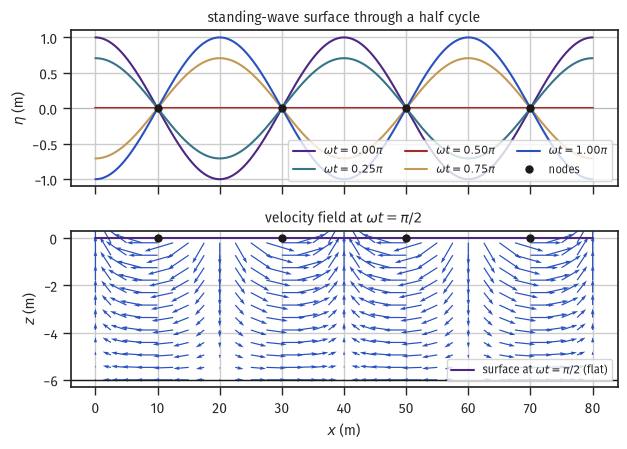

nodes at x = [10. 30. 50. 70.] m  (L/4 + n L/2, L = 40 m)
crest-to-trough height at antinodes = 2.0 m = 2 Hp


In [7]:
# Identity check, surface through a half cycle,
# velocity field at maximum flow (flat surface).
h_dep = 6.0
L = 40.0
k = 2 * np.pi / L
om = np.sqrt(g * k * np.tanh(k * h_dep))
Hp = 1.0
a = Hp / 2

x = np.linspace(0, 2 * L, 600)
t_rand = np.linspace(0, 2 * np.pi / om, 7)
err = max(np.abs(a * np.cos(k * x - om * t) + a * np.cos(k * x + om * t)
                 - Hp * np.cos(k * x) * np.cos(om * t)).max() for t in t_rand)
print(f"max |eta_+ + eta_-  -  Hp cos(kx) cos(om t)| = {err:.2e}\n")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fs.fullwidth * 0.85, 4.6), sharex=True)

# Surface at several phases
phases = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi]
for i, ph in enumerate(phases):
    ax1.plot(x, Hp * np.cos(k * x) * np.cos(ph), color=fs.color_list[i % len(fs.color_list)],
             label=rf"$\omega t = {ph / np.pi:.2f}\pi$")
nodes = np.arange(L / 4, 2 * L, L / 2)
ax1.plot(nodes, np.zeros_like(nodes), "ko", ms=5, zorder=5, label="nodes")
ax1.axhline(0, color="0.7", lw=0.5)
ax1.set_ylabel(r"$\eta$ (m)")
ax1.set_title("standing-wave surface through a half cycle")
ax1.legend(ncol=3, fontsize=8, loc="lower right")

# Velocity field at om t = pi/2 (surface flat, max velocities)
xv = np.linspace(0, 2 * L, 33)
zv = np.linspace(-h_dep, -0.2, 12)
XV, ZV = np.meshgrid(xv, zv)
U = -(2 * g * a * k / om) * np.cosh(k * (h_dep + ZV)) / np.cosh(k * h_dep) * np.sin(k * XV)
W = (2 * g * a * k / om) * np.sinh(k * (h_dep + ZV)) / np.cosh(k * h_dep) * np.cos(k * XV)
ax2.quiver(XV, ZV, U, W, color=fs.color_list[4], scale=25, width=0.0022)
ax2.plot(x, 0 * x, color=fs.color_list[0], lw=1.5, label=r"surface at $\omega t = \pi/2$ (flat)")
ax2.plot(nodes, np.zeros_like(nodes), "ko", ms=5, zorder=5)
ax2.axhline(-h_dep, color="k", lw=1)
ax2.set_xlabel(r"$x$ (m)")
ax2.set_ylabel(r"$z$ (m)")
ax2.set_title(r"velocity field at $\omega t = \pi/2$")
ax2.legend(fontsize=8, loc="lower right")

fig.tight_layout()
plt.show()

print(f"nodes at x = {nodes} m  (L/4 + n L/2, L = {L:.0f} m)")
print(f"crest-to-trough height at antinodes = {2 * Hp:.1f} m = 2 Hp")

## Problem 7. Solving the dispersion relation numerically.

Baseline case $T = 8$ s, $h = 10$ m, so $\omega = 2\pi/8 = 0.785398$ rad/s and $L_0 = gT^2/(2\pi) = 99.9238$ m. The converged answer, to seven figures, is

$$
k = 0.0886224\ \text{m}^{-1}, \qquad L = 70.8984\ \text{m}, \qquad kh = 0.886224 .
$$

$kh$ sits between $\pi/10$ and $\pi$, so this is intermediate depth and neither shortcut applies. We need a solver.

**(a) Fixed-point on $L$.** Rearranged, $L = L_0\tanh(2\pi h/L) \equiv G(L)$. Starting at $L = L_0 = 99.92$ m, the iterates *oscillate* about the root and close in slowly:

| $n$ | $L_n$ (m) |
|---:|---:|
| 0 | 99.9238 |
| 1 | 55.6799 |
| 2 | 80.9870 |
| 3 | 64.9809 |
| 4 | 74.6782 |
| 5 | 68.6010 |
| 6 | 72.3402 |
| 7 | 70.0109 |
| 8 | 71.4514 |

The oscillation comes from $G'(L^*) < 0$: the map overshoots the root and lands on the other side. Convergence is linear with ratio $|G'(L^*)| \approx 0.62$. Each iteration gains about a fifth of a digit, so six-figure agreement takes 25 to 30 iterations. It works, and it needs no derivative.

**(b) Newton on $k$.** With $f(k) = \omega^2 - gk\tanh kh$,

$$
f'(k) = -g\tanh kh - gkh\,\mathrm{sech}^2 kh .
$$

From the deep-water seed $k_0 = \omega^2/g = 0.0628797$ the residual drops as $10^{-2}$, $10^{-4}$, $10^{-9}$, $10^{-17}$. The number of correct digits roughly doubles each step: quadratic convergence. A handful of Newton iterations from a poor seed beat 27 of fixed point. The seed is always safe on the deep-water side: $\tanh kh < 1$ forces the true $k$ to be larger than $\omega^2/g$, and $f$ is monotone in $k$.

**(c) Hunt (1979).** The rational approximation gives $kh = 0.886126$ against the exact $0.886224$: a relative error of $1.1\times10^{-4}$ (about one part in ten thousand). That is accurate enough for engineering work. Use Hunt inside a loop over a thousand grid cells, where a Newton solve per cell is wasteful.

**(d) Behavior at $h = 2$ m and $h = 200$ m.**

| $h$ (m) | $kh$ | regime | fixed-point iterations | Newton iterations | Hunt rel. error |
|---:|---:|---|---:|---:|---:|
| 2 | 0.362 | shallow | 158 | 7 | $1.8\times10^{-4}$ |
| 10 | 0.886 | intermediate | 27 | 5 | $1.1\times10^{-4}$ |
| 200 | 12.58 | deep | 0 | 2 | $1.7\times10^{-6}$ |

The fixed-point map degrades badly in shallow water.

Write the map as $G(L) = L_0\tanh(2\pi h/L)$, so

$$
G'(L) = -L_0\,\frac{2\pi h}{L^2}\,\mathrm{sech}^2\!\left(\frac{2\pi h}{L}\right),
$$

and the convergence rate is $|G'(L^*)|$. In deep water $2\pi h/L$ is large, $\mathrm{sech}^2 \to 0$, and $G' \to 0$: the map is nearly constant. At $h = 200$ m the starting value $L_0$ is already the answer to six figures, so the iteration count is zero. In shallow water $\tanh x \approx x$ gives $G(L) \approx 2\pi h L_0/L$. Its root satisfies $L^{*2} \approx 2\pi h L_0$, so

$$
G'(L^*) \approx -\frac{2\pi h L_0}{L^{*2}} = -1 .
$$

The map becomes a reflection about the root, and convergence stalls: 158 iterations at $h = 2$ m against 27 at $h = 10$ m. The oscillation at $h = 10$ m is a milder case of the same $G' < 0$.

Newton has no such problem. It needs two extra steps in shallow water, since the deep-water seed $k_0 = \omega^2/g$ underestimates the true $k$ by a factor of three there. Once it is close, the convergence is quadratic in every regime. Hunt is worst in the shallow-to-intermediate band and two orders of magnitude better in deep water. A rational fit has its largest error where the fitted function curves most.

**(e) Depth sweep at $T = 8$ s.** The table in the code cell below gives $L$, $C$, and $h/L$, and flags where each shortcut is good to 1%.

The shallow-water shortcut $C = \sqrt{gh}$ reaches 1% only at $h = 0.94$ m ($h/L = 0.039$). That is tighter than the conventional $h/L < 1/20 = 0.05$ cutoff. The deep-water shortcut $C = gT/(2\pi)$ reaches 1% at $h = 41.8$ m ($h/L = 0.42$), looser than the conventional $h/L > 1/2$. So the deep-water formula is usable a bit before the textbook line, and the shallow-water one is not yet usable at its line. The classification cutoffs are drawn on $\tanh kh$ itself, and $C$ inherits only part of that error, so the two do not coincide. When someone tells you a wave is in "shallow water," ask what error they will tolerate.


In [8]:
# Three ways to invert omega^2 = g k tanh(kh)
def fixed_point_L(T, h, n=40):
    L0 = g*T**2/(2*np.pi)
    L = L0
    out = [L]
    for _ in range(n):
        L = L0*np.tanh(2*np.pi*h/L)
        out.append(L)
    return np.array(out)


def newton_k(T, h, n=8):
    omega = 2*np.pi/T
    k = omega**2/g
    out = [k]
    for _ in range(n):
        t = np.tanh(k*h)
        f = omega**2 - g*k*t
        fp = -g*t - g*k*h*(1 - t**2)
        k = k - f/fp
        out.append(k)
    return np.array(out)


def hunt_k(T, h):
    omega = 2*np.pi/T
    y = omega**2*h/g
    kh2 = y**2 + y/(1 + 0.6522*y + 0.4622*y**2 + 0.0864*y**4 + 0.0675*y**5)
    return np.sqrt(kh2)/h


T = 8.0
for h in (10.0, 2.0, 200.0):
    omega = 2*np.pi/T
    kN = newton_k(T, h)
    k_exact = kN[-1]
    L_exact = 2*np.pi/k_exact
    Ls = fixed_point_L(T, h, n=400)
    hits = np.nonzero(np.abs(Ls - L_exact) < 1e-6*L_exact)[0]
    n_fp = int(hits[0]) if hits.size else -1
    kH = hunt_k(T, h)
    res = np.abs(omega**2 - g*kN*np.tanh(kN*h))
    print(f'--- T = {T:.0f} s, h = {h:g} m ---')
    print(f'    exact k  = {k_exact:.7f} 1/m,  L = {2*np.pi/k_exact:.4f} m,  '
          f'kh = {k_exact*h:.5f}')
    print(f'    Newton residuals: ' + '  '.join(f'{r:.1e}' for r in res[:5]))
    print(f'    fixed point: {n_fp} iterations to six-figure L')
    print(f'    Hunt: kh = {kH*h:.6f}, relative error '
          f'{abs(kH - k_exact)/k_exact:.2e}\n')

print('first eight fixed-point iterates for h = 10 m:')
print('   ' + '  '.join(f'{v:.4f}' for v in fixed_point_L(T, 10.0)[:9]))

# (e) depth sweep with the shortcut checks
print(f'\n{"h (m)":>7s}{"L (m)":>10s}{"C (m/s)":>10s}{"h/L":>9s}'
      f'{"sqrt(gh) err":>14s}{"gT/2pi err":>13s}')
print('-'*63)
for h in (0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0, 50.0, 100.0, 200.0):
    k = newton_k(T, h)[-1]
    L = 2*np.pi/k
    C = L/T
    e_sh = abs(np.sqrt(g*h) - C)/C
    e_dp = abs(g*T/(2*np.pi) - C)/C
    tag_sh = ' *' if e_sh < 0.01 else '  '
    tag_dp = ' *' if e_dp < 0.01 else '  '
    print(f'{h:>7.1f}{L:>10.2f}{C:>10.3f}{h/L:>9.4f}'
          f'{e_sh:>12.1%}{tag_sh}{e_dp:>11.1%}{tag_dp}')
print('\n* marks a shortcut accurate to better than 1%')

# Depth at which each shortcut reaches 1% error
from scipy.optimize import brentq
def err_sh(h):
    C = (2*np.pi/newton_k(T, h)[-1])/T
    return abs(np.sqrt(g*h) - C)/C - 0.01
def err_dp(h):
    C = (2*np.pi/newton_k(T, h)[-1])/T
    return abs(g*T/(2*np.pi) - C)/C - 0.01
h_sh = brentq(err_sh, 0.05, 3.0)
h_dp = brentq(err_dp, 5.0, 200.0)
for h, lab in ((h_sh, 'shallow shortcut'), (h_dp, 'deep shortcut')):
    L = 2*np.pi/newton_k(T, h)[-1]
    print(f'{lab:>18s} reaches 1% at h = {h:6.2f} m,  h/L = {h/L:.4f}')

--- T = 8 s, h = 10 m ---
    exact k  = 0.0886224 1/m,  L = 70.8984 m,  kh = 0.88622
    Newton residuals: 2.7e-01  2.7e-02  9.3e-05  1.2e-09  1.1e-16
    fixed point: 27 iterations to six-figure L
    Hunt: kh = 0.886126, relative error 1.11e-04

--- T = 8 s, h = 2 m ---
    exact k  = 0.1811162 1/m,  L = 34.6915 m,  kh = 0.36223
    Newton residuals: 5.4e-01  8.1e-01  9.2e-02  2.6e-03  2.4e-06
    fixed point: 158 iterations to six-figure L
    Hunt: kh = 0.362298, relative error 1.80e-04

--- T = 8 s, h = 200 m ---
    exact k  = 0.0628797 1/m,  L = 99.9238 m,  kh = 12.57595
    Newton residuals: 1.5e-11  0.0e+00  0.0e+00  0.0e+00  0.0e+00
    fixed point: 0 iterations to six-figure L
    Hunt: kh = 12.575970, relative error 1.69e-06

first eight fixed-point iterates for h = 10 m:
   99.9238  55.6799  80.9870  64.9809  74.6782  68.6010  72.3402  70.0109  71.4514

  h (m)     L (m)   C (m/s)      h/L  sqrt(gh) err   gT/2pi err
--------------------------------------------------------

## Problem 8 (Graduate students only). Linearized BVP.

Linearize the Problem 5 system: drop all products of small quantities, and move the free-surface conditions from $z = \eta$ to $z = 0$. Both steps are $\mathcal{O}(\varepsilon)$ corrections (Problems 1 and 4). The result:

**Governing PDE — unchanged (it was already linear):**

$$
\boxed{\ \nabla^2\phi = 0, \qquad -h \le z \le 0. \ }
$$

The domain is now the *fixed* strip $-h \le z \le 0$. The boundary no longer moves.

**Bottom boundary condition — unchanged:**

$$
\boxed{\ \frac{\partial\phi}{\partial z} = 0, \qquad z = -h. \ }
$$

**Linearized KFSBC**, from $\dfrac{\partial\eta}{\partial t} + u\dfrac{\partial\eta}{\partial x} = w$: drop the quadratic $u\,\partial\eta/\partial x$, evaluate at $z = 0$, and write $w = -\partial\phi/\partial z$:

$$
\boxed{\ \frac{\partial\eta}{\partial t} = -\frac{\partial\phi}{\partial z}, \qquad z = 0. \ }
$$

**Linearized DFSBC**, from $-\dfrac{\partial\phi}{\partial t} + \tfrac{1}{2}|\vec{u}|^2 + g\eta = 0$: drop the quadratic $\tfrac{1}{2}|\vec{u}|^2$ and evaluate at $z = 0$:

$$
\boxed{\ -\frac{\partial\phi}{\partial t} + g\eta = 0
\quad\Longleftrightarrow\quad
\eta = \frac{1}{g}\frac{\partial\phi}{\partial t}\bigg|_{z=0}. \ }
$$

**Combined free-surface condition.** The two surface conditions share the unknown $\eta$, so eliminate it. Differentiate the DFSBC in time,

$$
\frac{\partial\eta}{\partial t} = \frac{1}{g}\frac{\partial^2\phi}{\partial t^2}\bigg|_{z=0},
$$

and substitute into the KFSBC:

$$
\frac{1}{g}\frac{\partial^2\phi}{\partial t^2} = -\frac{\partial\phi}{\partial z}
\qquad\Longrightarrow\qquad
\boxed{\ \frac{\partial^2\phi}{\partial t^2} + g\frac{\partial\phi}{\partial z} = 0, \qquad z = 0. \ }
$$

**Periodicity — unchanged:**

$$
\boxed{\ \phi(x, z, t) = \phi(x + L, z, t), \qquad \phi(x, z, t) = \phi(x, z, t + T). \ }
$$

**Confirmation that the Airy wave solves this system.** Take the separable solution from Week 5:

$$
\phi = -\frac{ga}{\omega}\frac{\cosh k(h+z)}{\cosh kh}\sin(kx - \omega t),
\qquad
\eta = a\cos(kx - \omega t).
$$

Check each condition in turn:

1. *Laplace*: $\dfrac{\partial^2\phi}{\partial x^2} = -k^2\phi$ and $\dfrac{\partial^2\phi}{\partial z^2} = +k^2\phi$ (differentiating $\cosh$ twice returns it with $+k^2$), so $\nabla^2\phi = 0$ identically.
2. *Bottom*: $\dfrac{\partial\phi}{\partial z} \propto \sinh k(h+z)$, which vanishes at $z = -h$. So we use the $\cosh k(h+z)$ vertical structure (rather than a bare $e^{kz}$).
3. *DFSBC*: $\dfrac{1}{g}\dfrac{\partial\phi}{\partial t}\bigg|_{z=0} = \dfrac{1}{g}\cdot ga\cos(kx - \omega t) = \eta$. Satisfied identically. This fixes the amplitude of $\phi$ in terms of $a$.
4. *KFSBC / combined condition*: $\dfrac{\partial^2\phi}{\partial t^2} = -\omega^2\phi$ and $g\dfrac{\partial\phi}{\partial z}\bigg|_{z=0} = gk\tanh(kh)\,\phi\big|_{z=0}$, so the combined condition requires

$$
\left(-\omega^2 + gk\tanh kh\right)\phi\big|_{z=0} = 0
\qquad\Longrightarrow\qquad
\omega^2 = gk\tanh kh.
$$

An arbitrary $(\omega, k)$ pair does not satisfy the last condition: it **selects** the allowed pairs. The linearized BVP admits the Airy wave when (and only when) frequency and wavenumber satisfy the dispersion relation. This is the system Week 5 solves, and the dispersion relation is its eigenvalue condition.

In [9]:
# Airy solution in each linearized condition; residuals via finite differences.
h_dep = 10.0
L = 40.0
k = 2 * np.pi / L
om = np.sqrt(g * k * np.tanh(k * h_dep))   # dispersion relation
a = 0.5

phi = lambda x, z, t: -(g * a / om) * np.cosh(k * (h_dep + z)) / np.cosh(k * h_dep) * np.sin(k * x - om * t)
eta = lambda x, t: a * np.cos(k * x - om * t)

d = 1e-4
x_ln = np.linspace(0, L, 200)
t0 = 0.7

lap = np.abs((phi(x_ln + d, -4.0, t0) - 2 * phi(x_ln, -4.0, t0) + phi(x_ln - d, -4.0, t0)) / d**2
             + (phi(x_ln, -4.0 + d, t0) - 2 * phi(x_ln, -4.0, t0) + phi(x_ln, -4.0 - d, t0)) / d**2).max()
bot = np.abs((phi(x_ln, -h_dep + d, t0) - phi(x_ln, -h_dep - d, t0)) / (2 * d)).max()
kfsbc = np.abs((eta(x_ln, t0 + d) - eta(x_ln, t0 - d)) / (2 * d)
               + (phi(x_ln, d, t0) - phi(x_ln, -d, t0)) / (2 * d)).max()
dfsbc = np.abs(-(phi(x_ln, 0.0, t0 + d) - phi(x_ln, 0.0, t0 - d)) / (2 * d) + g * eta(x_ln, t0)).max()
comb = np.abs((phi(x_ln, 0.0, t0 + d) - 2 * phi(x_ln, 0.0, t0) + phi(x_ln, 0.0, t0 - d)) / d**2
              + g * (phi(x_ln, d, t0) - phi(x_ln, -d, t0)) / (2 * d)).max()
period = np.abs(phi(x_ln + L, -4.0, t0) - phi(x_ln, -4.0, t0)).max()

print(f"Laplace residual                          = {lap:.2e}")
print(f"bottom BC residual (phi_z at z=-h)        = {bot:.2e}")
print(f"linearized KFSBC residual at z=0          = {kfsbc:.2e}")
print(f"linearized DFSBC residual at z=0          = {dfsbc:.2e}")
print(f"combined FSBC residual (phi_tt + g phi_z) = {comb:.2e}")
print(f"periodicity residual phi(x+L) - phi(x)    = {period:.2e}")
print(f"\ndispersion check: omega^2 - g k tanh(kh)  = {om**2 - g * k * np.tanh(k * h_dep):+.2e}")
print("All residuals at FD-truncation level: the Airy pair (phi, eta) solves the linearized BVP")
print("exactly, provided omega and k satisfy the dispersion relation.")

Laplace residual                          = 3.33e-07
bottom BC residual (phi_z at z=-h)        = 0.00e+00
linearized KFSBC residual at z=0          = 1.43e-09
linearized DFSBC residual at z=0          = 1.16e-08
combined FSBC residual (phi_tt + g phi_z) = 2.89e-07
periodicity residual phi(x+L) - phi(x)    = 4.44e-15

dispersion check: omega^2 - g k tanh(kh)  = -2.22e-16
All residuals at FD-truncation level: the Airy pair (phi, eta) solves the linearized BVP
exactly, provided omega and k satisfy the dispersion relation.


## Checks to remember

- Newton on $k$ doubles its correct digits each step. It beats fixed-point iteration on $L$ by about an order of magnitude in iteration count. Hunt's approximation is good to one part in $10^4$ with no iteration: use it inside a grid loop.
- Every boundary condition in the water-wave BVP is a level-set statement. The KFSBC is $DF/Dt = 0$ on $F = z - \eta$. The bottom condition is $\vec{u}\cdot\nabla G = 0$ on $G = z + h(x)$. Same method, top and bottom.
- Linearization discards terms of relative size $\varepsilon = ka$ in two places: quadratic products of unknowns, and the transfer of conditions from $z = \eta$ to $z = 0$. The numerical residuals show that both scale together.
- Laplace's equation is linear, so the interior is easy. The difficulty is at the free surface. Superposition is exact for the PDE but only approximate (to $\mathcal{O}(\varepsilon)$) for the full problem. The quadratic cross term in Problem 3 shows this.
- A standing wave doubles the crest-to-trough excursion of its progressive components. Its energy sloshes between all-potential (surface extreme, fluid at rest) and all-kinetic (surface flat, velocities maximal) twice per period.